# Bias-Variance Tradeoff

**Author:** Tohidul Islam Tareq

Polynomial regression example showing underfitting and overfitting.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (7, 4)


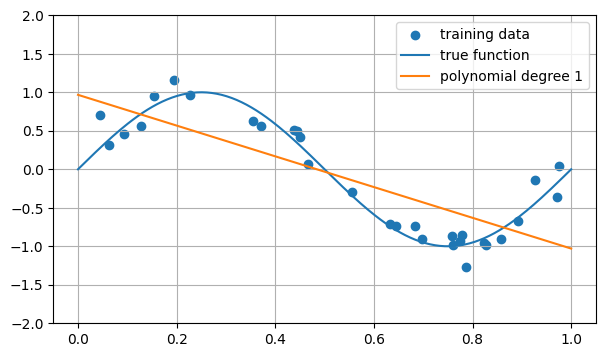

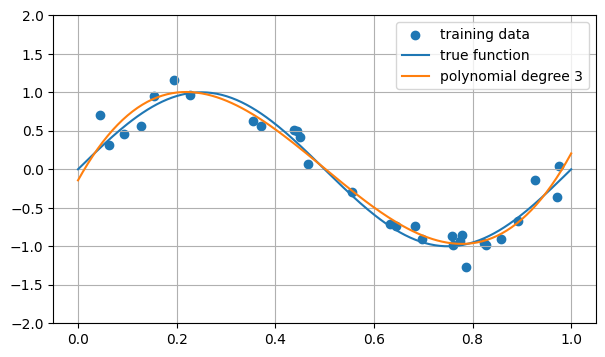

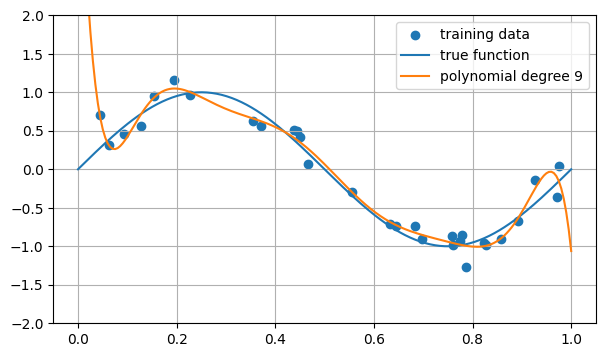

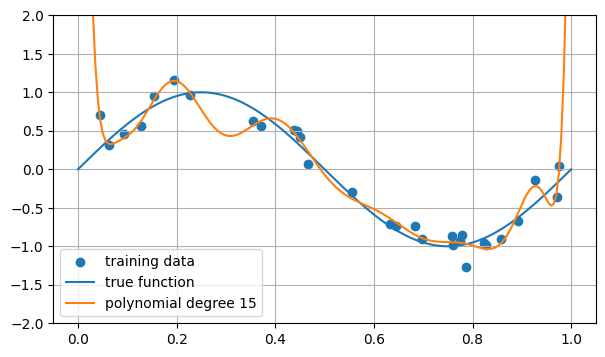

,degree,test_mse_against_true_curve
0,1,0.201724
1,3,0.005015
2,9,0.372420
3,15,3.959756


In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(RANDOM_STATE)
def true_function(x): return np.sin(2*np.pi*x)

X_train = np.sort(rng.uniform(0, 1, 30)).reshape(-1, 1)
y_train = true_function(X_train.ravel()) + rng.normal(0, 0.20, 30)
X_test = np.linspace(0, 1, 200).reshape(-1, 1)
y_test = true_function(X_test.ravel())

results = []
for degree in [1, 3, 9, 15]:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    results.append({'degree': degree, 'test_mse_against_true_curve': mse})
    plt.figure()
    plt.scatter(X_train, y_train, label='training data')
    plt.plot(X_test, y_test, label='true function')
    plt.plot(X_test, y_pred, label=f'polynomial degree {degree}')
    plt.ylim(-2, 2)
    plt.legend(); plt.grid(True); plt.show()

pd.DataFrame(results)
